The only difference between weakly supervised and self supervised RW-PINN code is the  RW-PINN loss function

# Importar librerías

In [1]:
#!pip install wiggle
#!pip install tensorflow-addons
#!pip install tensorflow-probability
import scipy.io as sio
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import numpy as np
from random import randint
from sklearn.metrics import mean_squared_error
#from wiggle.wiggle import wiggle
from matplotlib.pyplot import figure
import math
import tensorflow as tf

import os

2024-05-03 17:47:25.177396: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-03 17:47:25.177449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-03 17:47:25.179355: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-03 17:47:25.190135: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-03 17:47:26.223657: W tensorflow/compiler/tf2

In [2]:
#!pip install pydot

from keras import initializers
from keras.layers import Input, Dense, Activation, Flatten, Conv2D
from keras.layers import  Dropout

from keras.models import Model


from keras.callbacks import EarlyStopping, ModelCheckpoint

# from kt_utils import *

import keras.backend as K
K.set_image_data_format('channels_last')

import sklearn.model_selection
#import pydot

# Definición de Funciones

## Ondicula de Ricker

Text(0.5, 1.0, 'Source Wavelet')

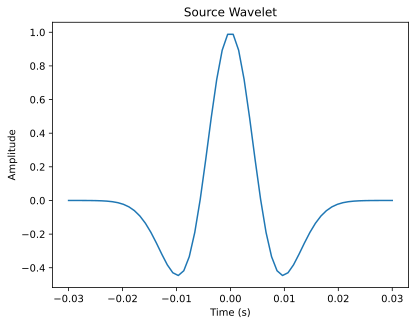

In [3]:
def ricker_wav(f,n,dt,t0):
    T = dt*(np.floor(n/2))
    t = np.linspace(-T,T,n)
    tau = t-t0
    pi=np.pi
    s = (1-2*tau*tau*f**2*pi**2)*np.exp(-tau**2*pi**2*f**2)
    rw = s
    return rw,t
 
freq=40
dt=10e-4
src_len=int(60)
wvlt,tt = ricker_wav(freq,src_len,dt,0)
plt.plot(tt,wvlt)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Source Wavelet")

## Modelo de Roca

In [4]:
def SoftSandNew(Kf,RHOf,Phi,Quartz,Clay,Feldspar,Limestone,Dolomite,Pressure,PhiC,Coordination,Fudge):
    # Uncemented sand rock physics model (modified to implement automatic-differentiation)
    #               INPUTS
    #
    #Kf				Fluid bulk modulus
    #RHOf			Fluid density
    #Phi			Porosity (fraction)
    #Quartz, etc.	Volume mineral content in solid phase (fraction)
    #Pressure		Effective pressure (MPa)
    #PhiC			Critical porosity ~0.4
    #Coordination	Coordination number ~6
    #Fudge			Reduction in shear stiffness -- 1 by default
    #
    #a is the contact radius between two spheres at input pressure

    #Balancing mineralogy
    Dolomite=1-(Quartz+Clay+Feldspar+Limestone)
    
    #Constants for clay
    RHOClay=2.65 
    KClay=21 
    GClay=7
    #Solid-phase elastic moduli
    KsV=Quartz*36.6+Clay*KClay+Limestone*76.8+Dolomite*94.9+Feldspar*75.6
    KsR=1/(Quartz/36.6+Clay/KClay+Limestone/76.8+Dolomite/94.9+Feldspar/75.6)
    Ks=0.5*(KsV+KsR)
    
    GsV=Quartz*45+Clay*GClay+Limestone*32+Dolomite*45+Feldspar*25.6
    GsR=1/(Quartz/45+Clay/GClay+Limestone/32+Dolomite/45+Feldspar/25.6)
    Gs=0.5*(GsV+GsR)
    Ms=Ks+(4/3)*Gs
    NUs=0.5*(Ms/Gs-2)/(Ms/Gs-1)
    
    #Solid-phase density
    RHOs=Quartz*2.65+Clay*RHOClay+Limestone*2.71+Dolomite*2.87+Feldspar*2.63
    
    #ILLITE
    #RHOs=2.58; Ms=RHOs.*4.32.*4.32; Gs=RHOs.*2.54.*2.54; NUs=0.5*(Ms./Gs-2)./(Ms./Gs-1); Ks=Ms-(4/3)*Gs;
    
    P=Pressure/1000
    C=Coordination
    
    #================== Dry Rock ====================
    #Effective K and G at PhiC
    #Hertz contact radius (R=1)
    a=tf.pow(((3*3.14*(1-NUs)/(2*C*(1-PhiC)*Gs))*P),(1/3))
    #Normal contact stiffness
    SN=4*a*Gs/(1-NUs)
    #Shear contact stiffness
    ST=8*a*Gs/(2-NUs)
    #Shear contact stiffness FUDGED (reduced)
    ST=ST/Fudge
    
    #Bulk modulus
    Khat=C*(1.-PhiC)*SN/(12*3.14)
    #Shear modulus
    Ghat=C*(1.-PhiC)*(SN+1.5*ST)/(20*3.14)
    
    #Effective bulk and shear moduli at porosity Phi<=PhiC
    KDry1=1/((Phi/PhiC)/(Khat+4*Ghat/3)+((PhiC-Phi)/PhiC)/(Ks+4*Ghat/3))-4*Ghat/3
    ZZ1=(Ghat/6)*(9*Khat+8*Ghat)/(Khat+2*Ghat)
    GDry1=1/((Phi/PhiC)/(Ghat+ZZ1)+((PhiC-Phi)/PhiC)/(Gs+ZZ1))-ZZ1
    MDry1 = KDry1+(4/3)*GDry1
    NuDry1=0.5*(MDry1/GDry1-2)/(MDry1/GDry1-1)
    
    #Effective bulk and shear moduli at porosity Phi>PhiC
    KDry2 = 1/(((1-Phi)/(1-PhiC))/(Khat+4*Ghat/3)+((Phi-PhiC)/(1-PhiC))/(4*Ghat/3))-4*Ghat/3
    ZZ2 = (Ghat/6)*(9*Khat+8*Ghat)/(Khat+2*Ghat)
    GDry2 = 1/(((1-Phi)/(1-PhiC))/(Ghat+ZZ2)+((Phi-PhiC)/(1-PhiC))/(ZZ2))-ZZ2
    MDry2 = KDry2+(4/3)*GDry2
    NuDry2=0.5*(MDry2/GDry2-2)/(MDry2/GDry2-1)
    
    MDry=MDry1*(tf.cast((Phi<=PhiC), tf.float64))+MDry2*(tf.cast((Phi>PhiC), tf.float64)) 
    GDry=GDry1*(tf.cast((Phi<=PhiC), tf.float64))+GDry2*(tf.cast((Phi>PhiC), tf.float64))
    NuDry=NuDry1*(tf.cast((Phi<=PhiC), tf.float64))+NuDry2*(tf.cast((Phi>PhiC), tf.float64))
    KDry=MDry-(4/3)*GDry
    
    # ================== Saturated Rock ============
    KSat=Ks*(Phi*KDry-(1+Phi)*Kf*KDry/Ks+Kf)/((1-Phi)*Kf+Phi*Ks-Kf*KDry/Ks)
    MSat=KSat+(4/3)*GDry
    RHOB=(1-Phi)*RHOs+Phi*RHOf
    Vp=tf.pow((MSat/RHOB),0.5)
    Vs=tf.pow((GDry/RHOB),0.5)
    Ip=Vp*RHOB
    PR=0.5*(MSat/GDry-2)/(MSat/GDry-1)
    
    return Vp,Vs,RHOB

## Coeficiente de Reflexión

In [5]:
def RC_fwd_model(vp1,d1,vp2,d2):
    
    Rpp= (vp2*d2-vp1*d1)/(vp2*d2+vp1*d1)
    
    return Rpp

# Definición de Parámetros Iniciales

In [6]:
Kg = 0.06
Kw = 2.61
RHOw = 1.01
RHOg = 0.18 
diffP = 16.5 
RHOs = 2.65
PhiC = 0.4 
Coordination = 14 
Fudge = 1
diffDepth = 1

# We have not analyzed the impact of partialsaturations or the presence of clay on the predictions
vclay=tf.cast(0,tf.float64)
sw=tf.cast(1,tf.float64)

2024-05-03 17:47:28.650918: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-03 17:47:28.717774: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-03 17:47:28.717890: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-03 17:47:28.720534: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-03 17:47:28.720663: I external/local_xla/xla/stream_executor

# Carga de Información

In [7]:
seis= np.load('../data_decatur/processed/seismic-ccs1-vw1-inline-time.npy')
phi_true = np.load('../data_decatur/processed/porosity-ccs1-vw1-inline.npy')

In [8]:
phi_max=np.max(phi_true) #can also take 1 or critical porosity (0.4)
phi_min=np.min(phi_true) #can also take 0

# Normalización de la Información

In [9]:
# Normalizing the input and output data  

seis_normalized = (seis - np.min(seis))/(np.max(seis)-np.min(seis))

#seis_compiled=np.concatenate((seis_normalized[:,0,:],seis_normalized[:,1,:]),axis=1)
seis_compiled=seis_normalized

true_output=np.zeros((seis_normalized.shape[0],124))
true_output[:,0:124]=(phi_true-phi_min)/(phi_max-phi_min)

seis_plus_petro_compiled=np.concatenate((seis_compiled,true_output),axis=1)

X_train,X_test,Y_train_unmasked,Y_test_unmasked = sklearn.model_selection.train_test_split(seis_normalized,seis_plus_petro_compiled, test_size=0.2, random_state=1)

X_train_final = np.expand_dims(np.expand_dims(X_train, axis=1),axis=3)
X_test_final = np.expand_dims(np.expand_dims(X_test, axis=1),axis=3)
mask_output_test=Y_test_unmasked[:,0:1]-Y_test_unmasked[:,0:1]
Y_test=np.concatenate((Y_test_unmasked,mask_output_test),axis=1)
mask_output_train=Y_train_unmasked[:,0:1]-Y_train_unmasked[:,0:1]
mask_no=4 ##number of prior known porosity logs
mask_output_train[0:mask_no,:]=1
Y_train=np.concatenate((Y_train_unmasked,mask_output_train),axis=1)

print ("number of training examples = " + str(X_train_final.shape[0]))
print ("number of test examples = " + str(X_test_final.shape[0]))
print ("X_train shape: " + str(X_train_final.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test_final.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 968
number of test examples = 243
X_train shape: (968, 1, 186, 1)
Y_train shape: (968, 311)
X_test shape: (243, 1, 186, 1)
Y_test shape: (243, 311)


In [10]:
## Denominators for normalizing the RMS error in the loss function
denom_phi= tf.reduce_sum(tf.where(Y_train[:,-1] ==1,tf.reduce_mean(Y_train[:,186:186+124],axis=1), Y_train[:,-1]))/mask_no
np.save("denom_phi.npy",denom_phi)

denom_seis= tf.reduce_mean(X_train)
np.save("denom_seis.npy",denom_seis)

2024-05-03 17:47:29.378604: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Text(0.5, 0, 'After normalisation')

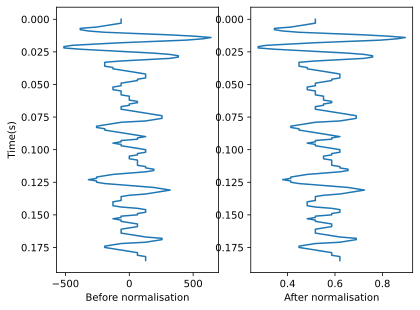

In [11]:
end_time=0.186
time_upscaled = np.arange(0, end_time, dt)

plt.subplot(1,2,1)
plt.plot(np.squeeze(seis[3,:]),time_upscaled)
plt.gca().invert_yaxis()
plt.ylabel('Time(s)')
plt.xlabel('Before normalisation')

plt.subplot(1,2,2)
plt.plot(np.squeeze(seis_normalized[3,:]),time_upscaled)
plt.gca().invert_yaxis()
plt.xlabel('After normalisation')

In [12]:
time_upscaled.shape

(186,)

In [13]:
def DecoderLinearInterpLayer(x,xp,fp):
    i = tf.clip_by_value(tf.searchsorted(xp, x, side='right'), 1, xp.shape[1] - 1)

    fp1=tf.gather(fp,indices=i-1, batch_dims=1)
    fp2=tf.gather(fp,indices=i, batch_dims=1)
    xp1=tf.gather(xp,indices=i-1, batch_dims=1)
    xp2=tf.gather(xp,indices=i, batch_dims=1)

    f = (fp1 *  (xp2 - x) + fp2 * (x - xp1)) / (xp2 - xp1)

    left=fp[0,0]
    right = fp[-1,-1]

    ff = tf.where(x < tf.ones_like(x)*tf.expand_dims(xp[:,0],axis=1), left, f)
    fff = tf.where(x > tf.ones_like(x)*tf.expand_dims(xp[:,-1],axis=1), tf.ones_like(x)*tf.expand_dims(fp[:,-1],axis=1), ff)
    return fff

# Arquitectura Red Neuronal

In [14]:
given_seed = 2

input_final = Input(shape=(X_train_final.shape[1:]))

## Encoder

In [15]:
#1
X = Conv2D(32, (1, 3), strides=(1, 2), name='conv0', padding='same',
           kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')(input_final)
X = Activation('relu')(X)

#2
X = Conv2D(64, (1, 7), strides=(1, 2), name='conv1',padding='same',
           kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')(X)
X = Activation('relu')(X)

#3
X = Conv2D(128, (1, 15), strides=(1, 2), name='conv2',padding='same',
           kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')(X)
X = Activation('relu')(X)

#4 
X = Conv2D(256, (1, 30), strides=(1, 2), name='conv3',padding='same',
           kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')(X)
X = Activation('relu')(X)
X = Dropout(rate=0.3, name='drop_conv3')(X)

# FLATTEN
X = Flatten()(X)
X = Dense(124, name='fc0',
          kernel_initializer=initializers.he_uniform(seed=given_seed), bias_initializer='zeros')(X)

encoded = Activation('tanh')(X) ##to scale the output between –1 and 1 before passing it as input to the decoder

## Decoder

In [16]:
encoded=tf.cast(encoded, tf.float64)

phi_for=((encoded + 1)/2) ##scaled between 0 and 1

phi=phi_for * (phi_max - phi_min) + phi_min + 1e-07

depth = np.arange(1,phi.shape[1]+1)*diffDepth

RHOf = sw*RHOw + (1 - sw) * RHOg
Kf = 1/(sw/Kw + (1 - sw)/Kg)

Vp_final,Vs_final,RHO_final=SoftSandNew(Kf,RHOf,phi,(1 - vclay)*0.8,vclay, (1 - vclay)*0.2,0,0,diffP, PhiC, Coordination, Fudge)

## Seismic Part

In [17]:
depth_diff = np.mean(np.diff(depth.T)) #Promedio de tasa de cambio de profundidad
time0=0.0/(Vp_final[:,0]) #Creo que esto asume que todo empieza en 0 pero mis datos empiezan mucho mas abajo en tiempo y profundidad.
time1 = 2*tf.cumsum(depth_diff/(Vp_final*1e3),axis=1)
time_final = tf.concat([tf.expand_dims(time0, axis=1),time1],axis=1)
time = time_final[:,0:-1]

time_new=tf.ones_like(time, dtype=tf.float64)

for i in range(len(time_upscaled)-time.shape[1]):
    time_new=tf.concat([time_new,tf.expand_dims(time0+1.0,axis=1)],axis=1)
    
pred_t=time_new*time_upscaled

Vp_time=DecoderLinearInterpLayer(pred_t,time,Vp_final)
RHO_time=DecoderLinearInterpLayer(pred_t,time,RHO_final)

Rpp_0=RC_fwd_model(Vp_time[:,0:-1],RHO_time[:,0:-1],Vp_time[:,1:],RHO_time[:,1:])
Rpplast=0.0/(Vp_time[:,0])
Rpp0=tf.concat([Rpp_0,tf.expand_dims(Rpplast, axis=1)],axis=1)

kernel_wvlt = tf.reshape(wvlt, [int(wvlt.shape[0]), 1, 1])
RC0 = tf.expand_dims(Rpp0, axis=2)
seis_for0=tf.squeeze(tf.nn.conv1d(RC0, tf.reverse(kernel_wvlt,[0]), 1,'SAME'),axis=2)
    
seis_for_normalized = (seis_for0 - np.min(seis))/(np.max(seis)-np.min(seis))

seis_for_final = tf.concat([seis_for_normalized,phi_for],axis=1)

In [18]:
print(input_final.shape)

(None, 1, 186, 1)


In [19]:
rw_pinn = Model(inputs=input_final, outputs=seis_for_final)
rw_pinn.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1, 186, 1)]          0         []                            
                                                                                                  
 conv0 (Conv2D)              (None, 1, 93, 32)            128       ['input_1[0][0]']             
                                                                                                  
 activation (Activation)     (None, 1, 93, 32)            0         ['conv0[0][0]']               
                                                                                                  
 conv1 (Conv2D)              (None, 1, 47, 64)            14400     ['activation[0][0]']          
                                                                                              

In [20]:
class loss_func(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
    def call(self, y_true, y_pred):
        mse_seis1 = tf.reduce_mean(tf.square(y_pred[:,0:186]-y_true[:,0:186]))
        
        return tf.math.sqrt(mse_seis1)

In [21]:
adam =tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False)
rw_pinn.compile(loss=loss_func(), optimizer = adam)

In [22]:
#import os
os.remove("rwpinn_model.h5")

In [23]:
# Using early stopping and Model Checkpoint
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=200)
mc = ModelCheckpoint('rwpinn_model.h5', monitor='val_loss', mode='min', verbose=1, save_weights_only=True)

## Entrenamiento

In [24]:
# Start the training

Batch_size=128
history = rw_pinn.fit(X_train_final, 
                      Y_train, 
                      validation_split=0.2, 
                      epochs=500, 
                      batch_size=Batch_size, 
                      callbacks=[es, mc],
                      verbose = 1)


Epoch 1/500


2024-05-03 17:47:42.515705: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/drop_conv3/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-05-03 17:47:43.017405: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-05-03 17:47:43.109525: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-05-03 17:47:45.130132: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f507308fae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-03 17:47:45.130179: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2024-05-03 17:47:45.139899: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproduc

7/7 [==============================] - ETA: 0s - loss: 0.1435
Epoch 1: saving model to rwpinn_model.h5
7/7 [==============================] - 12s 423ms/step - loss: 0.1435 - val_loss: 0.1452
Epoch 2/500
7/7 [==============================] - ETA: 0s - loss: 0.1435
Epoch 2: saving model to rwpinn_model.h5
7/7 [==============================] - 0s 63ms/step - loss: 0.1435 - val_loss: 0.1452
Epoch 3/500
7/7 [==============================] - ETA: 0s - loss: 0.1435
Epoch 3: saving model to rwpinn_model.h5
7/7 [==============================] - 0s 65ms/step - loss: 0.1435 - val_loss: 0.1452
Epoch 4/500
7/7 [==============================] - ETA: 0s - loss: 0.1435
Epoch 4: saving model to rwpinn_model.h5
7/7 [==============================] - 0s 62ms/step - loss: 0.1435 - val_loss: 0.1452
Epoch 5/500
6/7 [========================>.....] - ETA: 0s - loss: 0.1435
Epoch 5: saving model to rwpinn_model.h5
7/7 [==============================] - 0s 62ms/step - loss: 0.1435 - val_loss: 0.1452
Epoch

In [25]:
# load the saved model
rw_pinn.load_weights('rwpinn_model.h5')

# Verificación de Resultados

In [26]:
# Testing and evaluating the model
Batch_size=128
preds = rw_pinn.evaluate(X_test_final, Y_test, batch_size=Batch_size, verbose=0, sample_weight=None)
print()
print ("Loss = " + str(preds))



Loss = 0.1435546875


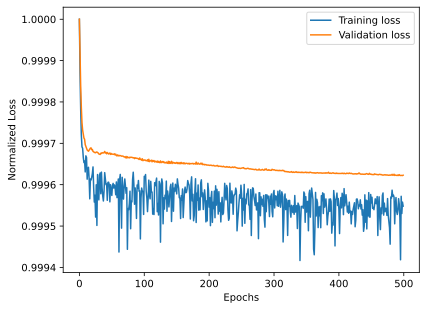

In [27]:
# Plotting the learning curve 
plt.plot(history.history['loss']/np.max(history.history['loss']))
plt.plot(history.history['val_loss']/np.max(history.history['val_loss']))

#plt.title('Learning curve')
plt.ylabel('Normalized Loss')
plt.xlabel('Epochs')
plt.legend(['Training loss', 'Validation loss'], loc='upper right')


In [28]:
## Only the Encoder part
rw_pinn_encoder = Model(inputs=input_final, outputs=encoded)

In [29]:
encoder_output_trainset = rw_pinn_encoder.predict(X_train_final)
phi_trainset_pred=((encoder_output_trainset+1)/2) * (phi_max - phi_min) + phi_min 

31/31 [==============================] - 1s 12ms/step


In [30]:
encoder_output_testset = rw_pinn_encoder.predict(X_test_final)
phi_testset_pred=((encoder_output_testset+1)/2) * (phi_max - phi_min) + phi_min

8/8 [==============================] - 0s 44ms/step


In [31]:
phi_trainset_true=Y_train[:,186:186+124] * (phi_max - phi_min) + phi_min
phi_testset_true=Y_test[:,186:186+124] * (phi_max - phi_min) + phi_min


In [32]:
phi_train_error=mean_squared_error(phi_trainset_true,phi_trainset_pred)
phi_test_error=mean_squared_error(phi_testset_true,phi_testset_pred)

print('Porosity Train error:',phi_train_error)
print('Porosity Test error:',phi_test_error)

Porosity Train error: 0.016392514458702316
Porosity Test error: 0.01631180700801346


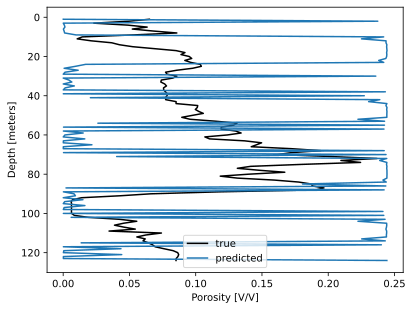

In [33]:
sample_number=300

plt.plot(phi_trainset_true[sample_number, :], depth, color = "black",label='true')
plt.plot(phi_trainset_pred[sample_number, :], depth,label='predicted')
plt.xlabel("Porosity [V/V]")
plt.ylabel("Depth [meters]")
plt.legend()
plt.gca().invert_yaxis()

In [34]:
## Only the Decoder part
rw_pinn_decoder = Model(inputs=encoded, outputs=seis_for_final)

In [35]:
decoder_output_trainset = rw_pinn_decoder.predict(encoder_output_trainset)
seis_output_trainset=decoder_output_trainset[:,0:186]

decoder_output_testset = rw_pinn_decoder.predict(encoder_output_testset)
seis_output_testset=decoder_output_testset[:,0:186]

8/8 [==============================] - 0s 16ms/step


Text(0, 0.5, 'Time')

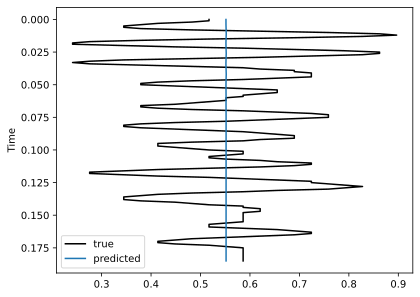

In [36]:
plt.plot(np.squeeze(X_train_final[sample_number,:,:]),time_upscaled, color = "black",label='true')
plt.plot(seis_output_trainset[sample_number,:],time_upscaled,label='predicted')
plt.gca().invert_yaxis()
plt.legend()
plt.ylabel('Time')


In [37]:
encoder_output_set = rw_pinn_encoder.predict(np.expand_dims(np.expand_dims(seis_normalized, axis=1),axis=3))
phi_set_pred=((encoder_output_set+1)/2) * (phi_max - phi_min) + phi_min

decoder_output_set = rw_pinn_decoder.predict(encoder_output_set)
seis_output_set=decoder_output_set[:,0:186]

38/38 [==============================] - 0s 9ms/step


In [38]:
phi_error=np.sqrt(mean_squared_error(phi_true,phi_set_pred))

print('Porosity RMS error:',phi_error)

Porosity RMS error: 0.12796999512514473


In [39]:
phi_train_error=np.sqrt(mean_squared_error(phi_trainset_true,phi_trainset_pred))
phi_test_error=np.sqrt(mean_squared_error(phi_testset_true,phi_testset_pred))

print('Porosity Trainset RMS error:',phi_train_error)
print('Porosity Testset RMS error:',phi_test_error)

Porosity Trainset RMS error: 0.1280332552843296
Porosity Testset RMS error: 0.12771768478959153


In [40]:
seis_error=np.sqrt(mean_squared_error(seis,seis_output_set*(np.max(seis)-np.min(seis))+ np.min(seis)))
seis_error_train=np.sqrt(mean_squared_error(np.squeeze(X_train_final)*(np.max(seis)-np.min(seis))+ np.min(seis),seis_output_trainset*(np.max(seis)-np.min(seis))+ np.min(seis)))
seis_error_test=np.sqrt(mean_squared_error(np.squeeze(X_test_final)*(np.max(seis)-np.min(seis))+ np.min(seis),seis_output_testset*(np.max(seis)-np.min(seis))+ np.min(seis)))

print('Seismic RMS error:',seis_error)
print('Seismic Train RMS error:',seis_error_train)
print('Seismic Test RMS error:',seis_error_test)

Seismic RMS error: 266.8275186064658
Seismic Train RMS error: 266.923847090781
Seismic Test RMS error: 266.443444637826


<Figure size 640x480 with 0 Axes>

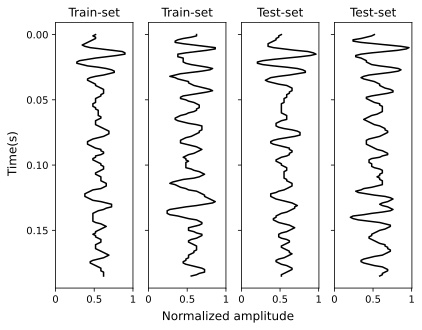

In [41]:
plt.figure()
fig, axs = plt.subplots(1, 4, sharey=True)
axs[0].plot(np.squeeze(X_train_final[34,:,:]),time_upscaled,'k')
axs[0].set_yticks([0,0.05,0.1,0.15])
axs[0].set_xticks([0,0.5,1])
axs[0].set_xticklabels(('0','0.5','1'))
axs[0].set_title('Train-set')

axs[1].plot(np.squeeze(X_train_final[64,:,:]),time_upscaled,'k')
axs[1].set_xticks([0,0.5,1])
axs[1].set_xticklabels(('0','0.5','1'))
axs[1].set_title('Train-set')

axs[2].plot(np.squeeze(X_test_final[21,:,:]),time_upscaled,'k')
axs[2].set_xticks([0,0.5,1])
axs[2].set_xticklabels(('0','0.5','1'))
axs[2].set_title('Test-set')

axs[3].plot(np.squeeze(X_test_final[26,:,:]),time_upscaled,'k')
axs[3].set_xticks([0,0.5,1])
axs[3].set_xticklabels(('0','0.5','1'))
axs[3].set_title('Test-set')

fig.supxlabel('Normalized amplitude')
fig.supylabel('Time(s)')

plt.gca().invert_yaxis()

<Figure size 640x480 with 0 Axes>

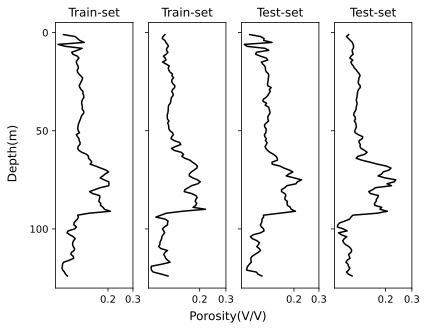

In [42]:
plt.figure()
fig, axs = plt.subplots(1, 4, sharey=True)
axs[0].plot(phi_trainset_true[34, :], depth,'k')
axs[0].set_yticks([0,50,100,150,200])
axs[0].set_xticks([0.2,0.3])
axs[0].set_title('Train-set')

axs[1].plot(phi_trainset_true[64, :], depth,'k')
axs[1].set_xticks([0.2,0.3])
axs[1].set_title('Train-set')

axs[2].plot(phi_testset_true[21, :], depth,'k')
axs[2].set_xticks([0.2,0.3])
axs[2].set_title('Test-set')

axs[3].plot(phi_testset_true[26, :], depth,'k')
axs[3].set_xticks([0.2,0.3])
axs[3].set_title('Test-set')

fig.supxlabel('Porosity(V/V)')
fig.supylabel('Depth(m)')

plt.gca().invert_yaxis()

<Figure size 640x480 with 0 Axes>

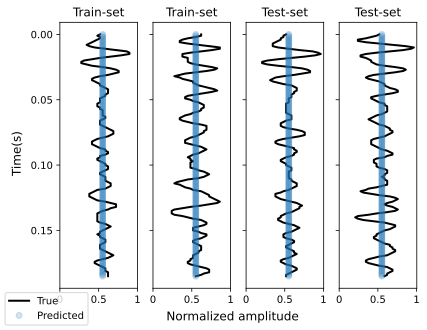

In [43]:
plt.figure()
fig, axs = plt.subplots(1, 4, sharey=True)
axs[0].plot(np.squeeze(X_train_final[34,:,:]),time_upscaled,'k',linewidth=2,label='True')
axs[0].plot(seis_output_trainset[34,:],time_upscaled,'o',alpha=0.2,label='Predicted')
axs[0].set_yticks([0,0.05,0.1,0.15])
axs[0].set_xticks([0,0.5,1])
axs[0].set_xticklabels(('0','0.5','1'))
axs[0].set_title('Train-set')

axs[1].plot(np.squeeze(X_train_final[64,:,:]),time_upscaled,'k',linewidth=2)
axs[1].plot(seis_output_trainset[64,:],time_upscaled,'o',alpha=0.2)
axs[1].set_xticks([0,0.5,1])
axs[1].set_xticklabels(('0','0.5','1'))
axs[1].set_title('Train-set')

axs[2].plot(np.squeeze(X_test_final[21,:,:]),time_upscaled,'k',linewidth=2)
axs[2].plot(seis_output_testset[21,:],time_upscaled,'o',alpha=0.2)
axs[2].set_xticks([0,0.5,1])
axs[2].set_xticklabels(('0','0.5','1'))
axs[2].set_title('Test-set')

axs[3].plot(np.squeeze(X_test_final[26,:,:]),time_upscaled,'k',linewidth=2)
axs[3].plot(seis_output_testset[26,:],time_upscaled,'o',alpha=0.2)
axs[3].set_xticks([0,0.5,1])
axs[3].set_xticklabels(('0','0.5','1'))
axs[3].set_title('Test-set')

fig.supxlabel('Normalized amplitude')
fig.supylabel('Time(s)')
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower left')

plt.gca().invert_yaxis()

<Figure size 640x480 with 0 Axes>

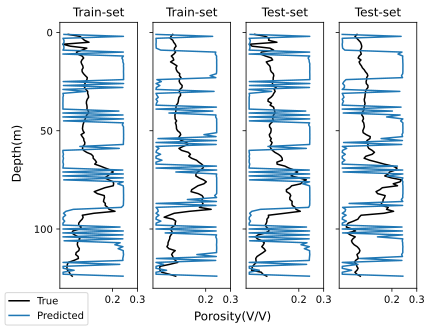

In [44]:
plt.figure()
fig, axs = plt.subplots(1, 4, sharey=True)
axs[0].plot(phi_trainset_true[34, :], depth,'k',label='True')
axs[0].plot(phi_trainset_pred[34, :], depth,label='Predicted')
axs[0].set_yticks([0,50,100,150,200])
axs[0].set_xticks([0.2,0.3])
axs[0].set_title('Train-set')

axs[1].plot(phi_trainset_true[64, :], depth,'k')
axs[1].plot(phi_trainset_pred[64, :], depth)
axs[1].set_xticks([0.2,0.3])
axs[1].set_title('Train-set')

axs[2].plot(phi_testset_true[21, :], depth,'k')
axs[2].plot(phi_testset_pred[21, :], depth)
axs[2].set_xticks([0.2,0.3])
axs[2].set_title('Test-set')

axs[3].plot(phi_testset_true[26, :], depth,'k')
axs[3].plot(phi_testset_pred[26, :], depth)
axs[3].set_xticks([0.2,0.3])
axs[3].set_title('Test-set')

fig.supxlabel('Porosity(V/V)')
fig.supylabel('Depth(m)')
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower left')

plt.gca().invert_yaxis()